Epoch 12/100: 100%|███████████████████████████████████████████████████████████████| 8941/8941 [00:31<00:00, 282.40it/s]


Early stopping triggered.


C:\Users\udays\AppData\Local\Temp\ipykernel_14328\856703342.py:195: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(os.path.join(results_folde

Training complete. Results saved.


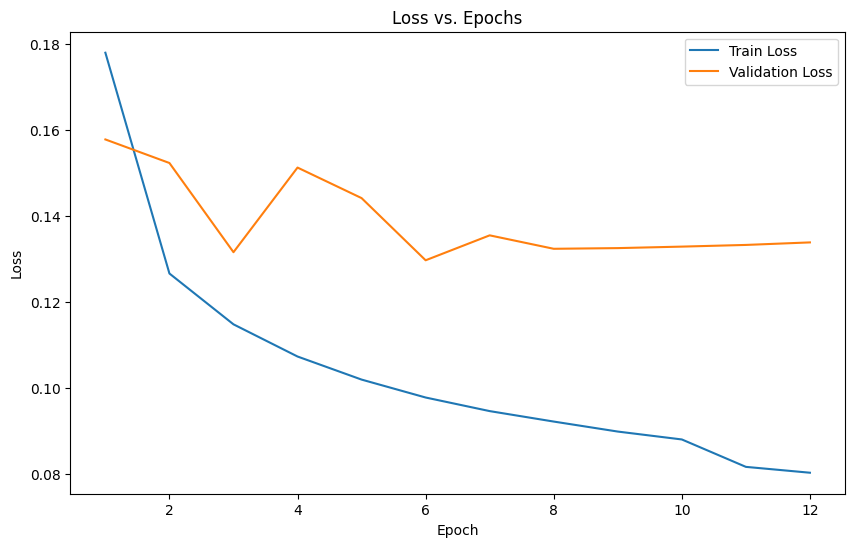

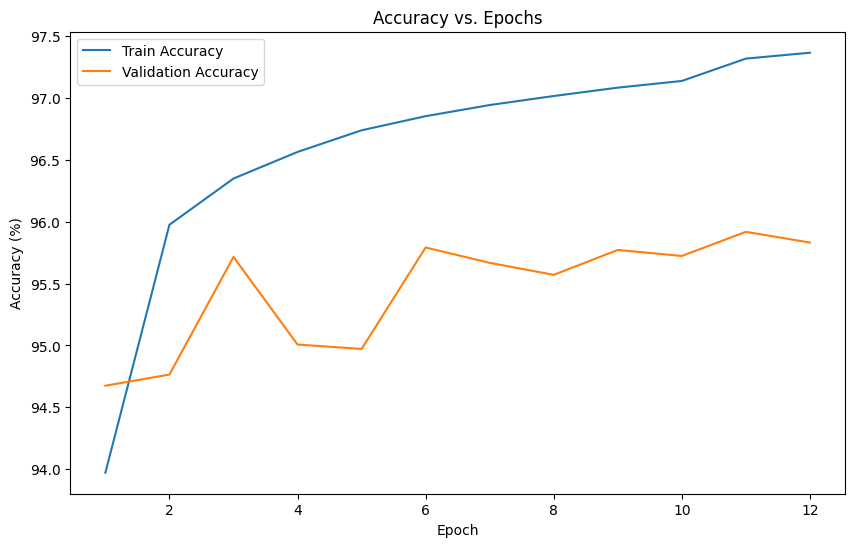

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from torch.optim.lr_scheduler import StepLR
import os
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt

# Hyperparameters
input_size = 432
hidden_sizes = [128, 256, 512, 1024, 512, 256, 64, 16]
output_size = 1
batch_size = 256
learning_rate = 0.0001
weight_decay = 1e-5
num_epochs = 100
early_stopping_patience = 6
lr_step_size = 10
lr_gamma = 0.5
# dropout_rate = 0.5
results_folder = 'D:/Kansas/data/10_counties_10km_matched_shapes/model_training_results/FCNN/RGB_NIR_minmax_norm_clip_10k'

# Create results folder if it doesn't exist
os.makedirs(results_folder, exist_ok=True)

# Paths to data
data_folder = 'D:/Kansas/data/10_counties_10km_matched_shapes/processed_data/RGB_NIR_minmax_clipping_10k/'
train_inputs_path = os.path.join(data_folder, 'train_inputs.npy')
train_labels_path = os.path.join(data_folder, 'train_labels.npy')
val_inputs_path = os.path.join(data_folder, 'val_inputs.npy')
val_labels_path = os.path.join(data_folder, 'val_labels.npy')
test_inputs_path = os.path.join(data_folder, 'test_inputs.npy')
test_labels_path = os.path.join(data_folder, 'test_labels.npy')

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Model Definition with Dropout
class FCNN(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):
        super(FCNN, self).__init__()
        layers = []
        prev_size = input_size
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_size, h))
            layers.append(nn.ReLU())
            # layers.append(nn.Dropout(p=dropout_rate))
            prev_size = h
        layers.append(nn.Linear(prev_size, output_size))
        layers.append(nn.Sigmoid())
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

# Load data
train_inputs = torch.tensor(np.load(train_inputs_path), dtype=torch.float32).to(device)
train_labels = torch.tensor(np.load(train_labels_path), dtype=torch.float32).to(device).view(-1, 1)
train_labels = (train_labels == 255).float()
val_inputs = torch.tensor(np.load(val_inputs_path), dtype=torch.float32).to(device)
val_labels = torch.tensor(np.load(val_labels_path), dtype=torch.float32).to(device).view(-1, 1)
val_labels = (val_labels == 255).float()
test_inputs = torch.tensor(np.load(test_inputs_path), dtype=torch.float32).to(device)
test_labels = torch.tensor(np.load(test_labels_path), dtype=torch.float32).to(device).view(-1, 1)
test_labels = (test_labels == 255).float()

# Create DataLoader
train_loader = DataLoader(TensorDataset(train_inputs, train_labels), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(val_inputs, val_labels), batch_size=batch_size)
test_loader = DataLoader(TensorDataset(test_inputs, test_labels), batch_size=batch_size)

# Initialize model, loss, optimizer, and scheduler
model = FCNN(input_size, hidden_sizes, output_size).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = StepLR(optimizer, step_size=lr_step_size, gamma=lr_gamma)

# Metrics storage
metrics = {
    'epoch': [], 'train_loss': [], 'val_loss': [],
    'train_accuracy': [], 'val_accuracy': [],
    'train_f1': [], 'val_f1': [],
    'train_precision': [], 'val_precision': [],
    'train_recall': [], 'val_recall': []
}

# Training loop
best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(num_epochs):
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    train_predictions, train_true = [], []

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        predicted = (outputs >= 0.5).float()
        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)
        train_predictions.extend(predicted.cpu().numpy())
        train_true.extend(labels.cpu().numpy())

    train_loss /= train_total
    train_accuracy = 100 * train_correct / train_total
    train_f1 = f1_score(train_true, train_predictions)
    train_precision = precision_score(train_true, train_predictions)
    train_recall = recall_score(train_true, train_predictions)

    # Validation phase
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    val_predictions, val_true = [], []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            predicted = (outputs >= 0.5).float()
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)
            val_predictions.extend(predicted.cpu().numpy())
            val_true.extend(labels.cpu().numpy())

    val_loss /= val_total
    val_accuracy = 100 * val_correct / val_total
    val_f1 = f1_score(val_true, val_predictions)
    val_precision = precision_score(val_true, val_predictions)
    val_recall = recall_score(val_true, val_predictions)

    # Save metrics
    metrics['epoch'].append(epoch + 1)
    metrics['train_loss'].append(train_loss)
    metrics['val_loss'].append(val_loss)
    metrics['train_accuracy'].append(train_accuracy)
    metrics['val_accuracy'].append(val_accuracy)
    metrics['train_f1'].append(train_f1)
    metrics['val_f1'].append(val_f1)
    metrics['train_precision'].append(train_precision)
    metrics['val_precision'].append(val_precision)
    metrics['train_recall'].append(train_recall)
    metrics['val_recall'].append(val_recall)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), os.path.join(results_folder, 'best_model.pth'))
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= early_stopping_patience:
        print("Early stopping triggered.")
        break

    scheduler.step()

# Save metrics to CSV
metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv(os.path.join(results_folder, 'training_metrics.csv'), index=False)

# Plot learning curves
plt.figure(figsize=(10, 6))
plt.plot(metrics['epoch'], metrics['train_loss'], label='Train Loss')
plt.plot(metrics['epoch'], metrics['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss vs. Epochs')
plt.savefig(os.path.join(results_folder, 'loss_curve.png'))

plt.figure(figsize=(10, 6))
plt.plot(metrics['epoch'], metrics['train_accuracy'], label='Train Accuracy')
plt.plot(metrics['epoch'], metrics['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Accuracy vs. Epochs')
plt.savefig(os.path.join(results_folder, 'accuracy_curve.png'))

# Test set evaluation
model.load_state_dict(torch.load(os.path.join(results_folder, 'best_model.pth')))
model.eval()

test_predictions, test_true = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        predicted = (outputs >= 0.5).float()
        test_predictions.extend(predicted.cpu().numpy())
        test_true.extend(labels.cpu().numpy())

test_f1 = f1_score(test_true, test_predictions)
test_precision = precision_score(test_true, test_predictions)
test_recall = recall_score(test_true, test_predictions)
test_conf_matrix = confusion_matrix(test_true, test_predictions)

# Save test results
with open(os.path.join(results_folder, 'test_metrics.txt'), 'w') as f:
    f.write(f'Test F1 Score: {test_f1:.4f}\n')
    f.write(f'Test Precision: {test_precision:.4f}\n')
    f.write(f'Test Recall: {test_recall:.4f}\n')
    f.write(f'Test Confusion Matrix:\n{test_conf_matrix}\n')

print("Training complete. Results saved.")